# MLP на Eigen: эксперимент MNIST

Обучение сети `784 → 128 → 10`, оценка классификации, времени CPU-инференса и памяти.

Сохранённые графики и таблицы относятся к исходному запуску Eigen-реализации. При повторном запуске значения времени могут отличаться.


In [12]:
from pathlib import Path
import sys

project_root = next((path for path in (Path.cwd(), *Path.cwd().parents)
                     if (path / "CMakeLists.txt").is_file()), None)
if project_root is None:
    raise RuntimeError("Start Jupyter inside the mlp-accelerator-sim project")
sys.path.insert(0, str(project_root / "build" / "python"))
data_dir = project_root / "data"

from nn import MLP, SGD
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from tqdm import tqdm
from time import perf_counter

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [13]:
batch_size = 32
epochs = 30
architecture = [784, 128, 10]
lr = 0.3

In [14]:
full_train = datasets.MNIST(root=str(data_dir), train=True, download=True, transform=transforms.ToTensor())
train_data, validation_data = random_split(full_train, [50000, 10000], generator=torch.Generator().manual_seed(seed))
validation_loader = DataLoader(validation_data, batch_size=batch_size, shuffle=False, num_workers=0)
class_names = full_train.classes
num_classes = len(class_names)
one_hot = np.eye(num_classes, dtype=np.float32)
print(f"Train: {len(train_data)}, validation: {len(validation_data)}")

Train: 50000, validation: 10000


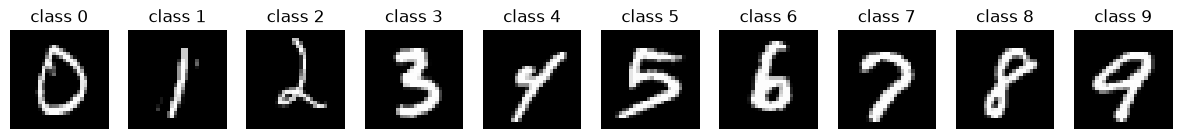

In [15]:
fig, axes = plt.subplots(1, num_classes, figsize=(15, 2))
seen = set()
for x, y in validation_data:
    y_int = int(y)
    if y_int not in seen:
        seen.add(y_int)
        axes[y_int].imshow(x.squeeze().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[y_int].set_title(f"class {y_int}")
        axes[y_int].axis("off")
    if len(seen) == num_classes:
        break

In [16]:
class MeanSquaredError:
    def __call__(self, targets, outputs):
        return np.sum((outputs - targets) ** 2) / (2 * len(targets))

    def grad(self, targets, outputs):
        return (outputs - targets) / len(targets)


def evaluate(model, loader):
    criterion = MeanSquaredError()
    total_loss = 0.0
    correct = 0
    count = 0
    for images, labels in loader:
        x = images.flatten(1).numpy()
        y = labels.numpy()
        predictions = model.predict(x)
        total_loss += criterion(one_hot[y], predictions) * len(y)
        correct += np.count_nonzero(predictions.argmax(axis=1) == y)
        count += len(y)
    return total_loss / count, correct / count

In [17]:
model = MLP(architecture, seed=seed)
criterion = MeanSquaredError()
optimizer = SGD(model.parameters(), lr=lr)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,
                          generator=torch.Generator().manual_seed(seed), num_workers=0)

history = {"train_loss": [], "validation_loss": [], "train_accuracy": [], "validation_accuracy": []}
training_seconds = 0.0

for epoch in range(epochs):
    total_loss = 0.0
    correct = 0
    count = 0
    epoch_started = perf_counter()
    with tqdm(train_loader, desc=f"ep {epoch + 1}/{epochs}", unit="batch") as progress:
        for images, labels in progress:
            x = images.flatten(1).numpy()
            y = labels.numpy()
            targets = one_hot[y]

            optimizer.zero_grad()
            predictions = model.forward(x)
            loss = criterion(targets, predictions)
            model.backward(criterion.grad(targets, predictions))
            optimizer.step()

            total_loss += loss * len(y)
            correct += np.count_nonzero(predictions.argmax(axis=1) == y)
            count += len(y)

            progress.set_postfix(loss=f"{total_loss / count:.4f}", accuracy=f"{correct / count:.1%}", refresh=False)
    training_seconds += perf_counter() - epoch_started
    validation_loss, validation_accuracy = evaluate(model, validation_loader)
    history["train_loss"].append(total_loss / count)
    history["train_accuracy"].append(correct / count)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(validation_accuracy)

ep 30/30: 100%|██████████| 1563/1563 [00:06<00:00, 243.22batch/s, accuracy=97.0%, loss=0.0289]


In [18]:
result = {
    "lr": lr,
    "epochs": epochs,
    "train_accuracy": history["train_accuracy"][-1],
    "validation_accuracy": history["validation_accuracy"][-1],
    "validation_loss": history["validation_loss"][-1],
    "training_seconds": training_seconds
}
pd.DataFrame([result])

,lr,epochs,train_accuracy,validation_accuracy,validation_loss,training_seconds
0,0.3,30,0.96962,0.9579,0.036328,197.695952


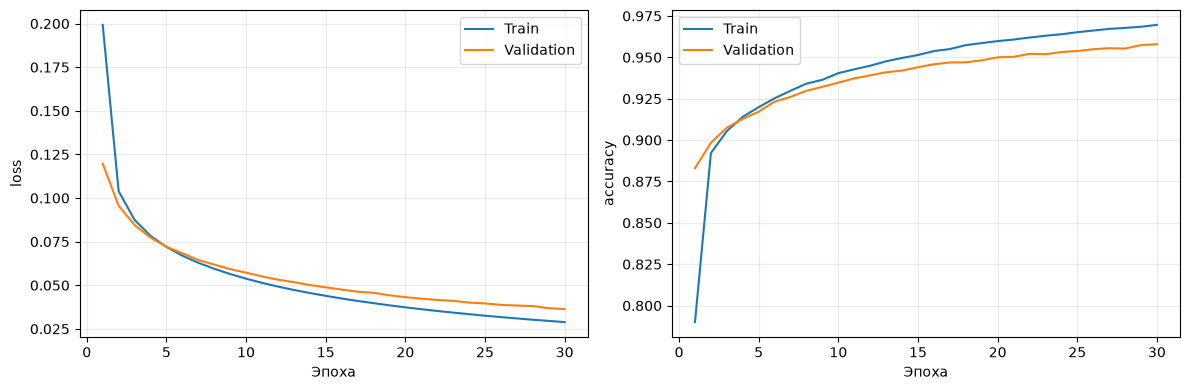

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epoch_axis = np.arange(1, len(history["train_loss"]) + 1)
for axis, metric in zip(axes, ["loss", "accuracy"]):
    axis.plot(epoch_axis, history["train_" + metric], label="Train")
    axis.plot(epoch_axis, history["validation_" + metric], label="Validation")
    axis.set(xlabel="Эпоха", ylabel=metric)
    axis.grid(alpha=0.25)
    axis.legend()
fig.tight_layout()

In [20]:
test_data = datasets.MNIST(root=str(data_dir), train=False, download=True, transform=transforms.ToTensor())
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0)
test_criterion = MeanSquaredError()
test_loss = 0.0
test_predictions = []
test_labels = []
for images, labels in test_loader:
    x = images.flatten(1).numpy()
    y = labels.numpy()
    predictions = model.predict(x)
    test_loss += test_criterion(one_hot[y], predictions) * len(y)
    test_predictions.append(predictions.argmax(axis=1))
    test_labels.append(y)
test_predictions = np.concatenate(test_predictions)
test_labels = np.concatenate(test_labels)
test_loss /= len(test_data)
test_accuracy = np.mean(test_predictions == test_labels)
test_results = pd.DataFrame([{**result, "test_loss": test_loss, "test_accuracy": test_accuracy}]).round({
    "train_accuracy": 4, "validation_accuracy": 4, "validation_loss": 4,
    "training_seconds": 1, "test_loss": 4, "test_accuracy": 4
})
test_results

,lr,epochs,train_accuracy,validation_accuracy,validation_loss,training_seconds,test_loss,test_accuracy
0,0.3,30,0.9696,0.9579,0.0363,197.7,0.0327,0.9633


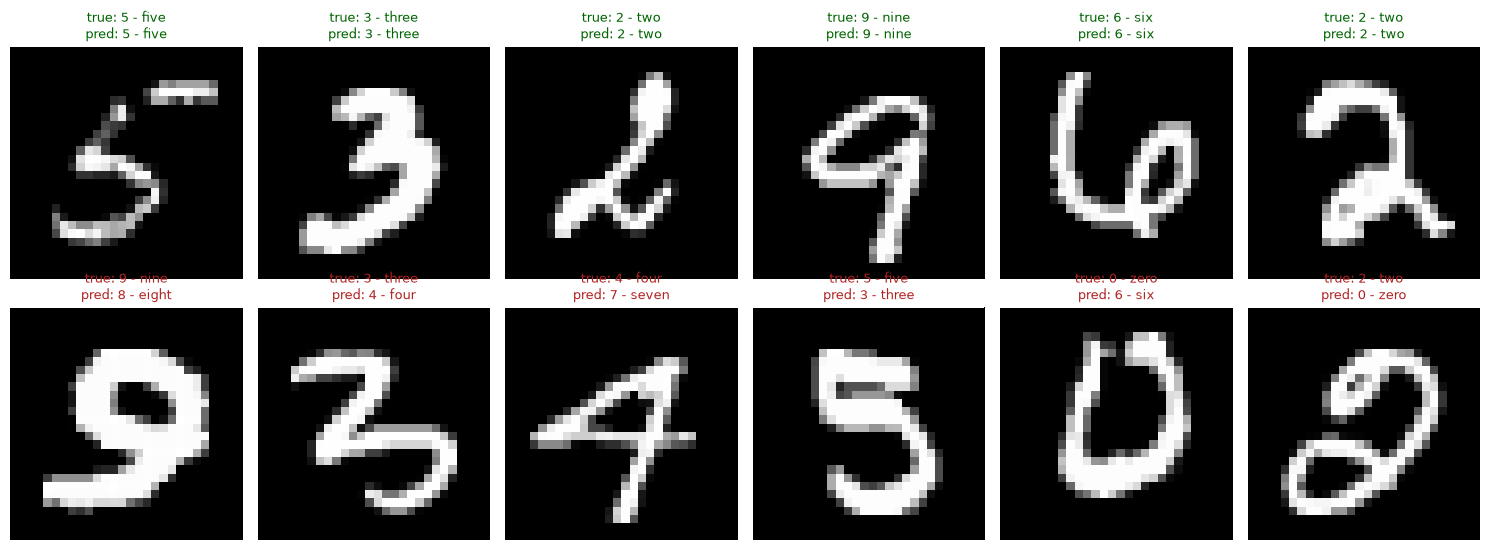

In [23]:
examples_per_group = 6
rng = np.random.default_rng(seed)
fig, axes = plt.subplots(2, examples_per_group, figsize=(2.5 * examples_per_group, 5.5), squeeze=False)
for row, correct in enumerate([True, False]):
    candidates = np.flatnonzero((test_predictions == test_labels) == correct)
    selected = rng.choice(candidates, size=min(examples_per_group, len(candidates)), replace=False)
    for column, axis in enumerate(axes[row]):
        axis.axis("off")
        if column < len(selected):
            index = selected[column]
            axis.imshow(test_data.data[index].numpy(), cmap="gray", vmin=0, vmax=255)
            axis.set_title(f"true: {class_names[test_labels[index]]}\npred: {class_names[test_predictions[index]]}",
                           color="darkgreen" if correct else "firebrick", fontsize=9)
fig.tight_layout()

In [22]:
from timeit import repeat

inference_images, _ = next(iter(validation_loader))
inference_x = inference_images.flatten(1).numpy()
for _ in range(10):
    model.predict(inference_x)

inference_seconds = np.array(repeat(lambda: model.predict(inference_x), repeat=5, number=100)) / 100
mean_inference_seconds = inference_seconds.mean()
inference_results = pd.DataFrame([{
    "batch_size": len(inference_x),
    "mean_ms_per_batch": mean_inference_seconds * 1000,
    "amortized_us_per_image": mean_inference_seconds * 1e6 / len(inference_x),
    "images_per_second": len(inference_x) / mean_inference_seconds
}])
inference_results

,batch_size,mean_ms_per_batch,amortized_us_per_image,images_per_second
0,32,0.278695,8.709225,114820.779073


## Память исходного CPU-запуска

inference: batch=32, peak=1244023 bytes (1.186 MiB)

training: batch=32, peak=1242056 bytes (1.185 MiB)

### Оценка памяти параметров и градиентов
$$
M = (784 \cdot 128 + 128 + 128 \cdot 10 + 10) \cdot 4 \cdot 2 = 814\,160\ \text{байт} \approx 0{,}776\ \text{MiB}.
$$
